In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [14]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 6292
# final number of annotated genes: 6016

# intron-containing genes
intron_genes<- final_iso_tb  %>% filter(blockCount > 1) %>% pull(gene_id) %>% sort() %>% unique()
final_iso_tb<- final_iso_tb %>% filter(gene_id %in% intron_genes)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]

# final number of annotated isoforms: 551
# final number of annotated genes: 275

[1] 6016

[1] 6292

[1] 275

[1] 551

In [12]:
count_all<- read.table(file = '../data/13_mature_rna_count.tsv', sep = "\t", header = T, row.names = 1, check.names = FALSE)

In [37]:
mature_tx<- '../data/rna/matureRNA/isoquant/260121_teloprime_tx_alignment_annot_by_splicing_isoform_counts.tsv'
count<- read.table(mature_tx, header = TRUE, sep = "\t")

# reformat to same output with flair
count<- count %>% 
    mutate(iso_id = str_split_i(isoform, ":", 1)) %>% 
    mutate(gene_id = str_split_i(iso_id, "_", 1)) %>%
    mutate(iso = paste0(isoform, "_", gene_id)) %>%
    filter(gene_id %in% intron_genes) %>% 
    select(iso, ys18_rep1, ys18_rep2, ys18_rep3, ym209_rep1, ym209_rep2, ym209_rep3) %>% 
    arrange(iso) %>% 
    column_to_rownames(var= "iso") 

colnames(count)<- c("WT rep1", "WT rep2",  "WT rep3", "MUT rep1", "MUT rep2",  "MUT rep3")
RPK = count_all/1000
sc_factor = colSums(RPK)/ 1e6
tpm<- countToTPM(count, normalize_by_len = FALSE, scaling_factor = sc_factor)

write.table(x = count, file = '../data/13_mature_rna_splicing_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm, file = '../data/13_mature_rna_splicing_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

## DESeq2

In [38]:
count<- read.table('../data/13_mature_rna_splicing_count.tsv', header = T, row.names = 1, sep = '\t')
tpm<- read.table('../data/13_mature_rna_splicing_tpm.tsv', header = T, row.names = 1, sep = '\t')

smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<-tpm[keep,]
n_genes<- length(str_split_i(rownames(tpm), ":", 1) %>% sort() %>% unique())
paste0("number of genes : ", n_genes) 
paste0("number of isoforms: ", dim(tpm)[1])

.
FALSE  TRUE 
  755   929 

[1] "number of genes : 254"

[1] "number of isoforms: 929"

In [39]:
coldata = data.frame(condition = str_split_i(colnames(count), "\\.", 1), batch = rep(1, ncol(count)))
coldata

rownames(coldata) = colnames(count)

dds <- DESeqDataSetFromMatrix(countData = count,
                              colData = coldata,
                              design = ~ condition)
dds
dds$condition <- relevel(dds$condition, ref = "WT")
dds <- DESeq(dds)
res <- results(dds)
resLFC <- lfcShrink(dds, coef="condition_MUT_vs_WT", type="apeglm")
deseq_tpm<- counts(dds, normalized = TRUE)
write.table(x = deseq_tpm, file = '../data/13_mature_rna_splicing_tpm_norm_by_deseq2.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

condition,batch
<chr>,<dbl>
WT,1
WT,1
WT,1
MUT,1
MUT,1
MUT,1


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 929 6 
metadata(1): version
assays(1): counts
rownames(929): ACT1:IR_ACT1 ACT1:downstream_ACT1 ...
  YSF3:intronicStart_YSF3 YSF3:spliced_YSF3
rowData names(0):
colnames(6): WT.rep1 WT.rep2 ... MUT.rep2 MUT.rep3
colData names(2): condition batch

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [41]:
de_df<- analyzeDESeq(res, resLFC, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)

In [87]:
iso_level

[1] antisense     downstream    firstExon     intronic      intronicEnd  
[6] intronicStart IR            spliced      
8 Levels: antisense downstream firstExon intronic ... spliced

In [201]:
iso_level

[1] antisense     downstream    firstExon     intronic      intronicEnd  
[6] intronicStart IR            spliced      
8 Levels: antisense downstream firstExon intronic ... spliced

In [90]:
iso_level<- de_df$feature_id %>% sort() %>% unique()

mcolors <- c("#5E8C61FF",
             "#FFC857FF",
             "#D0AF84", 
             "#ADB9A1",
             "#8CBDBC",
             "#F0A96B",
             "#068D9D",
             "#B44E3FFF")
names(mcolors) = iso_level

mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")

In [55]:
de_df$class= final_iso_tb[match(de_df$gene_id, final_iso_tb$gene_id), "class"]
de_df$class<- factor(de_df$class, levels = c('low', 'medium', 'high'))
de_df$feature_id<- factor(de_df$feature_id, levels = iso_level)

write.table(x = de_df, file = '../data/13_mature_rna_splicing_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

In [84]:
df1<- de_df %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(de_df, class, name = 'total'))

df2<- de_df %>%
    count(labels, feature_id, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)

iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low", labels == "Up in MUT") %>% 
    arrange(-p) %>% pull(feature_id)

iso_levels<- c(iso_levels, iso_level[!c(iso_level %in% iso_levels)])

write.table(df2 %>% select(class, feature_id, labels, n, total_per_label, total, p_per_label, p),
          '../data/13_mature_rna_splicing_DE_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


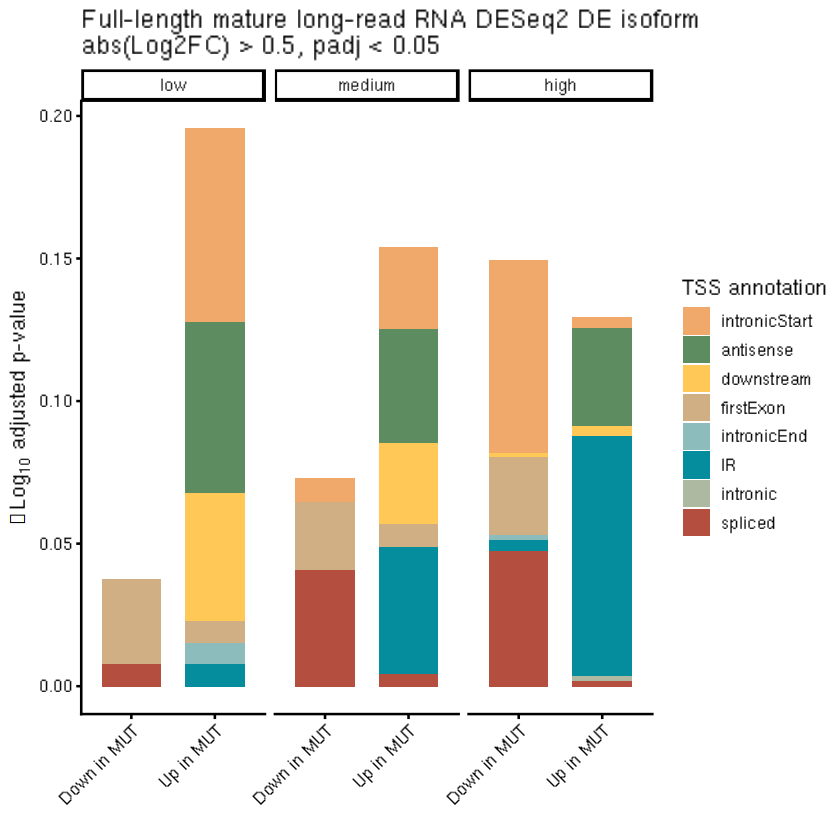

In [91]:
p1<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation")  +
    facet_wrap(vars(class), ncol = 3)

ggsave("../figures/Supp_mature_rna_splicing_percentage_of_isoform_by_expr_with_sig.pdf", p1, width = 6, height = 3)

p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation") +
    facet_wrap(vars(class), ncol = 3) 
p2
ggsave("../figures/Supp_mature_rna_splicing_percentage_of_isoform_by_expr.pdf", p2, width = 6, height = 3)

In [203]:
de_df %>% filter(feature_id == "IR") %>% arrange(-log2FoldChange)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,lfcShrink,labels,gene_id,iso_id,feature_id,annotation,class
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<fct>,<chr>,<fct>
RIM1:IR_RIM1,33.519315,3.430840,0.5011719,6.845636,7.613669e-12,7.858999e-10,3.2899074,Up in MUT,RIM1,RIM1:IR,IR,NA,high
NCE101:IR_NCE101,4.797517,2.498320,1.0317160,2.421519,1.545580e-02,5.091646e-02,1.4591130,Not sig,NCE101,NCE101:IR,IR,NA,medium
AIM11:IR_AIM11,14.334924,2.341246,0.6161628,3.799720,1.448599e-04,1.332424e-03,2.0187021,Up in MUT,AIM11,AIM11:IR,IR,NA,medium
RUB1:IR_RUB1,61.937751,2.327567,0.3168498,7.345964,2.042816e-13,4.744441e-11,2.2464473,Up in MUT,RUB1,RUB1:IR,IR,NA,medium
DYN2:IR_DYN2,11.267323,2.011366,0.6432561,3.126851,1.766895e-03,9.433595e-03,1.5877823,Up in MUT,DYN2,DYN2:IR,IR,NA,high
RPS17A:IR_RPS17A,8.629520,2.010619,0.7285871,2.759613,5.786985e-03,2.432629e-02,1.4424123,Up in MUT,RPS17A,RPS17A:IR,IR,NA,high
SNC1:IR_SNC1,18.900749,2.008193,0.4952293,4.055077,5.011781e-05,5.819930e-04,1.7763721,Up in MUT,SNC1,SNC1:IR,IR,NA,medium
DID4:IR_DID4,6.107600,1.954064,0.8571056,2.279841,2.261713e-02,6.691501e-02,1.0490614,Not sig,DID4,DID4:IR,IR,NA,medium
RPS0A:IR_RPS0A,24.892614,1.837010,0.5014972,3.663051,2.492286e-04,2.067262e-03,1.5710847,Up in MUT,RPS0A,RPS0A:IR,IR,NA,high


In [94]:
## fraction of genes with DE isoforms in splicing

In [96]:
all_genes<- de_df$gene_id %>% sort() %>% unique()
ds_genes<- de_df %>% distinct(labels, gene_id) %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()

In [135]:
df<- final_iso_tb %>% rownames_to_column("rownames") %>% 
    filter(gene_id %in% (de_df$gene_id %>% sort() %>% unique())) %>% 
    distinct(gene_id, class) %>% 
    column_to_rownames("gene_id") 

df$splicing_de = "Not sig"
df[ds_genes, 'splicing_de'] = "DE"

df<- df %>% count(class, name = 'total') %>% 
    left_join(count(df, class, splicing_de)) %>% 
    mutate(frac = n/total)

df$class<- factor(df$class, levels = c('low', 'medium', 'high'))

mcol = c("#fb8072", "")
names(mcol) = c("DE", "Not sig")

Joining with `by = join_by(class)`


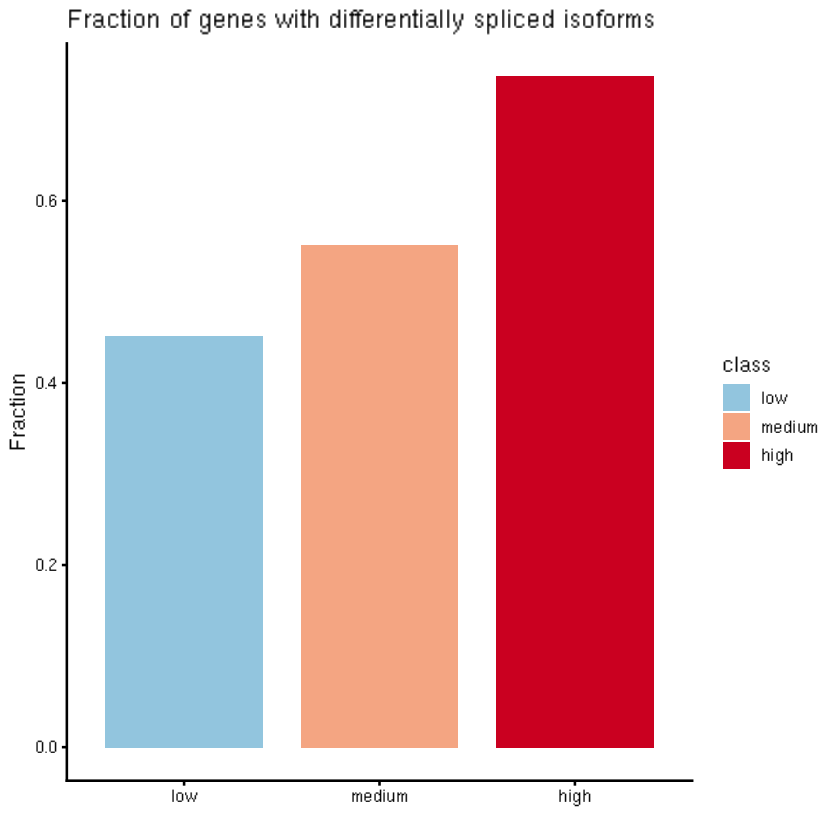

In [167]:
mcolors <- c("#92c5de", "#f4a582", "#ca0020")
names(mcolors)<- c("low", "medium", "high")

df %>% 
    filter(splicing_de == "DE") %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
    geom_bar(stat = "identity", width = 0.8) +
    scale_fill_manual(values = class_colors) +
    labs(x = '', y = "Fraction", title = "Fraction of genes with differentially spliced isoforms")

ggsave('../figures/Supp_mature_rna_splicing_fraction_of_de_genes_by_expr.pdf', width = 4, height = 3.5)

## genes with alternative splicing vs genes with chromatin change

In [ ]:
all_genes<- de_df$gene_id %>% sort() %>% unique()
ds_genes<- de_df %>% distinct(labels, gene_id) %>% filter(labels != "Not sig") %>% pull(gene_id) %>% sort() %>% unique()

In [189]:
diff_nuc<- read.table(file = '../data/5_chromatin_diff_chrom_results.tsv', sep = '\t', header = T, row.names = 1)
df<- diff_nuc[!diff_nuc %>% arrange(gene_id, pval) %>% pull(gene_id) %>% duplicated(), ]

In [200]:
df %>% select(gene_id, pval_adj_WT, mean_MUT, mean_WT, delta, type, config, splicing_change) %>% arrange(splicing_change)

,gene_id,pval_adj_WT,mean_MUT,mean_WT,delta,type,config,splicing_change
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
128,ACT1,1.067570e-15,0.4745917,0.78749725,-0.3129055498,co-accessible,co-accessible,DE
327,AIM11,6.299058e-14,0.2213221,0.13137551,0.0899465729,co-accessible,co-accessible,DE
654,APE2,2.031015e-07,0.2783435,0.33929283,-0.0609492970,co-accessible,co-accessible,DE
729,APS3,4.725270e-23,0.2084135,0.17728932,0.0311241593,not sig,co-accessible,DE
794,ARF2,4.510038e-03,0.3885650,0.38913443,-0.0005694097,not sig,co-accessible,DE
902,ARP2,8.220191e-46,0.2694357,0.14751420,0.1219215087,co-accessible,co-accessible,DE
926,ARP9,3.345331e-08,0.3878404,0.11199187,0.2758485667,co-accessible,co-accessible,DE
1368,BET1,3.225279e-01,0.1178936,0.04400645,0.0738871081,co-accessible,co-accessible,DE
1450,BMH2,6.927466e-01,0.9445125,0.59309179,0.3514207397,co-accessible,co-accessible,DE


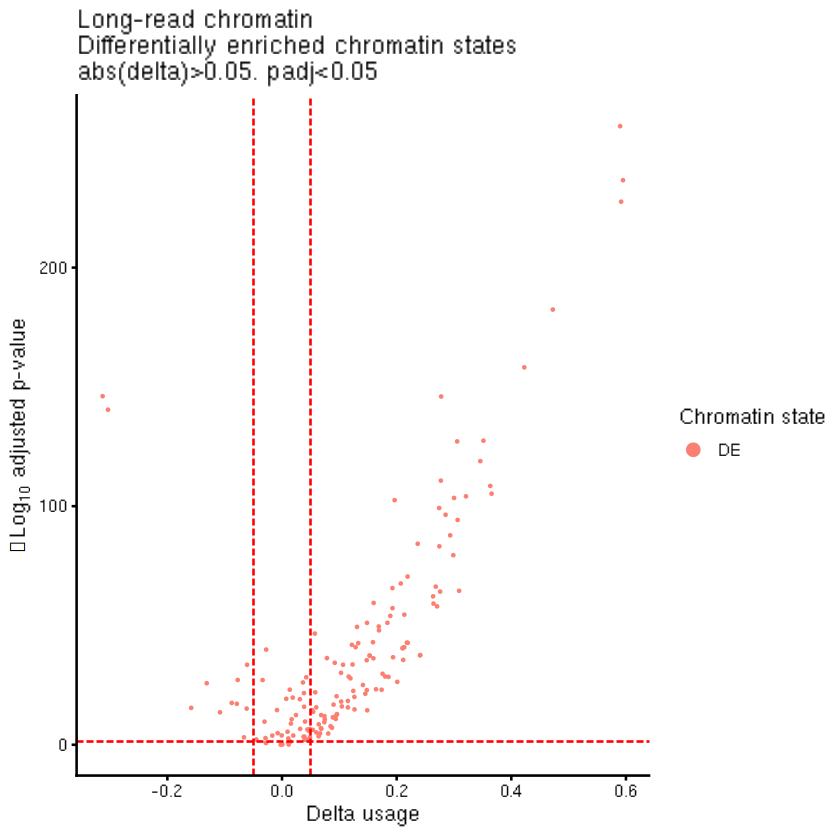

In [191]:
df$splicing_change = "Not sig"
df[df$gene_id %in% ds_genes, "splicing_change"] = "DE"

mcol = c("#fb8072", "grey20")
names(mcol) = c("DE", "Not sig")

delta_cutoff = 0.05
df %>%
    filter(splicing_change != "Not sig") %>% 
    ggplot(aes(x = delta, y = -log10(pval_adj))) +
    geom_point(aes(color = splicing_change), size = 0.2) +
    labs(x = expression("Delta usage"),y = expression(-Log[10] * " adjusted p-value"), 
         title = "Long-read chromatin\nDifferentially enriched chromatin states\nabs(delta)>0.05. padj<0.05", 
         color = "Chromatin state") +
    geom_vline(xintercept = delta_cutoff, color = 'red', linetype = "longdash") +
    geom_vline(xintercept = -delta_cutoff, color = 'red', linetype = "longdash") +
    geom_hline(yintercept = -log10(0.05), color = 'red', linetype = "longdash") +
    scale_color_manual(values = mcol) +
    guides(color = guide_legend(override.aes = list(size = 3)))

# ggsave("../figures/Figure1E_chrom_state_volcano.pdf",  width = 6, height = 3)